In [1]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

In [2]:
urls = [
    "https://zoon.ru/msk/business/type/svedenie_i_mastering/",
    "https://zoon.ru/msk/business/type/svedenie_i_mastering/page-2/",
    "https://zoon.ru/msk/business/type/svedenie_i_mastering/page-3/",
    "https://zoon.ru/msk/business/type/studii_zvukozapisi/",
    "https://zoon.ru/msk/business/type/studii_zvukozapisi/page-2/",
    "https://zoon.ru/msk/business/type/studii_zvukozapisi/page-3/",
    "https://zoon.ru/msk/business/type/studii_zvukozapisi/?v%5B4f84a6953c72ddd76600000c%5D%5Bкруглосуточно%5D=круглосуточно&search_query_form=1",
    "https://zoon.ru/msk/business/type/studii_zvukozapisi/?require_org_link=true&search_query_form=1",
    "https://zoon.ru/msk/business/type/svedenie_i_mastering/page-2/?v%5B4f84a6953c72ddd76600000c%5D%5B2%5D=2&search_query_form=1"
]
headers = {
    "User-Agent": "Mozilla/5.0"
}
all_reviews = []
for url in urls:

    response = requests.get(url, headers=headers)

    soup = BeautifulSoup(response.text, "html.parser")

    reviews = soup.find_all("div", class_="minicard-item__comment z-mt--8")

    for review in reviews:
        text = review.text.strip()

        all_reviews.append(text)

    print(f"Собрано отзывов: {len(all_reviews)}")

df = pd.DataFrame({
    "review": all_reviews
})


df = df.drop_duplicates()

Собрано отзывов: 29
Собрано отзывов: 51
Собрано отзывов: 66
Собрано отзывов: 95
Собрано отзывов: 117
Собрано отзывов: 132
Собрано отзывов: 154
Собрано отзывов: 157
Собрано отзывов: 157


In [3]:
len(df)

92

In [4]:
df["review"] = df["review"].str.replace("\xa0", " ")

In [5]:
urls = [
    "https://vk.com/search/statuses?c%5Bq%5D=%D1%81%D1%82%D1%83%D0%B4%D0%B8%D1%8F%20%D0%B7%D0%B2%D1%83%D0%BA%D0%BE%D0%B7%D0%B0%D0%BF%D0%B8%D1%81%D0%B8&q=%D1%81%D1%82%D1%83%D0%B4%D0%B8%D1%8F%20%D0%B7%D0%B2%D1%83%D0%BA%D0%BE%D0%B7%D0%B0%D0%BF%D0%B8%D1%81%D0%B8"


]

headers = {
    "User-Agent": "Mozilla/5.0"
}

for url in urls:

    response = requests.get(url, headers=headers)

    soup = BeautifulSoup(response.text, "html.parser")

    reviews = soup.find_all("div", class_="vkitSpacing__root--S4nqJ")

    for review in reviews:
        text = review.text.strip()

        all_reviews.append(text)

    print(f"Собрано отзывов: {len(all_reviews)}")

df = pd.DataFrame({
    "review": all_reviews
})


df = df.drop_duplicates()

len(df)

df["review"] = df["review"].str.replace("\xa0", " ")

Собрано отзывов: 157


In [6]:
len(df)

92

In [7]:
df.to_csv("reviews.csv", index=False)

In [8]:
from collections import Counter
import re

In [9]:
all_text = " ".join(df["review"])

all_text = all_text.lower()

words = re.findall(r"\b[а-яё]+\b", all_text)

In [10]:
stopwords = [
    "и", "в", "на", "с", "что", "это", "очень", 'как', 'так', 'мне',
    "все", "для", "по", "но", "не", "а", "из", 'раз', 'всё',
    "к", "у", "же", "бы", "то", "от", "до", 'студия', 'звукозаписи', 'студии', 'студию',
    'спасибо'
]

filtered_words = [
    word for word in words
    if word not in stopwords and len(word) > 2
]

In [11]:
word_counts = Counter(filtered_words)

word_counts.most_common(20)

[('записи', 9),
 ('ребята', 8),
 ('рекомендую', 8),
 ('уже', 8),
 ('отличная', 8),
 ('сразу', 7),
 ('работу', 7),
 ('сделали', 7),
 ('ещё', 6),
 ('супер', 6),
 ('записать', 6),
 ('качественно', 6),
 ('всем', 6),
 ('запись', 6),
 ('просто', 6),
 ('атмосфера', 6),
 ('профессионалы', 6),
 ('радует', 5),
 ('результат', 5),
 ('люди', 5)]

In [12]:
import matplotlib.pyplot as plt

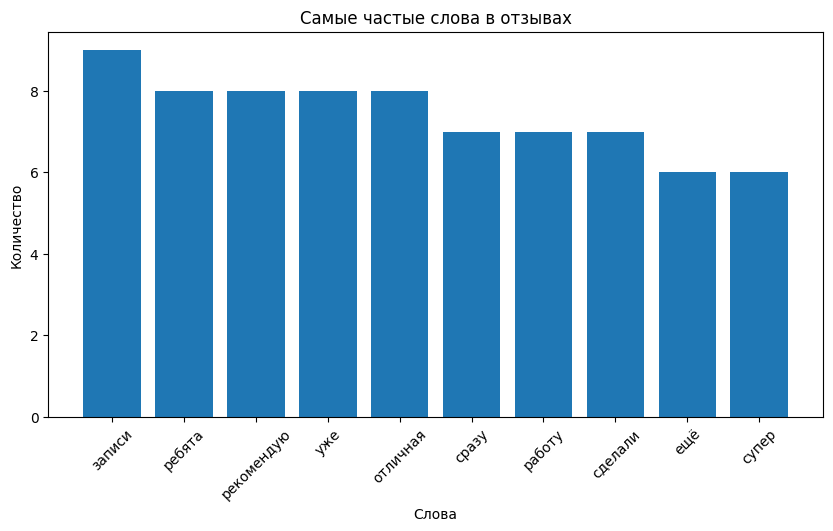

In [13]:
top_words = word_counts.most_common(10)

words = [word[0] for word in top_words]
counts = [word[1] for word in top_words]

plt.figure(figsize=(10,5))
plt.bar(words, counts)

plt.title("Самые частые слова в отзывах")
plt.xlabel("Слова")
plt.ylabel("Количество")

plt.xticks(rotation=45)

plt.show()

In [14]:
categories = {
    "Качество звука": ["звук", "звучание", "запись", "записи", "сведение", "мастеринг", "качество", "трек", "песня", "песню"],
    "Профессионализм": ["профессионалы", "профессионально", "мастер", "специалист", "ребята", "команда", "персонал"],
    "Атмосфера и комфорт": ["атмосфера", "комфорт", "уют", "уютно", "место", "приятно", "классное", "круто"],
    "Цена": ["цена", "стоимость", "дешево", "недорого", "дорого", "прайс"],
    "Скорость и удобство": ["быстро", "сразу", "удобно", "записаться", "время", "день"],
    "Результат": ["результат", "сделали", "получилось", "доволен", "довольна", "рекомендую"]
}

category_counts = {}

for category, keywords in categories.items():
    count = 0
    for review in df["review"].str.lower():
        if any(keyword in review for keyword in keywords):
            count += 1
    category_counts[category] = count

category_df = pd.DataFrame({
    "category": list(category_counts.keys()),
    "count": list(category_counts.values())
})

category_df["share"] = category_df["count"] / len(df) * 100

category_df.sort_values("count", ascending=False)

,category,count,share
0,Качество звука,53,57.608696
2,Атмосфера и комфорт,24,26.086957
4,Скорость и удобство,21,22.826087
1,Профессионализм,20,21.739130
5,Результат,20,21.739130
3,Цена,4,4.347826


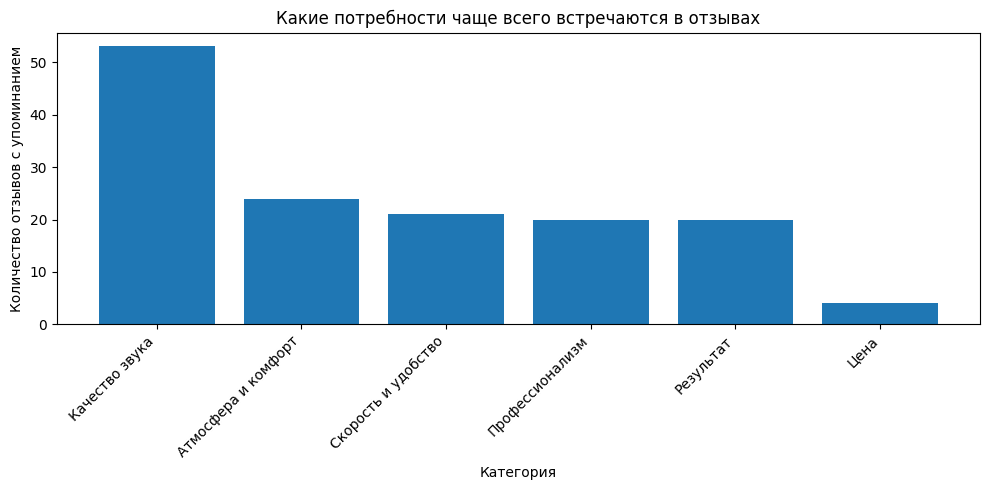

In [15]:
category_df = category_df.sort_values("count", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(category_df["category"], category_df["count"])

plt.title("Какие потребности чаще всего встречаются в отзывах")
plt.xlabel("Категория")
plt.ylabel("Количество отзывов с упоминанием")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()